# SVM: Pilot positive control (Ictal vs. pre-ictal: 1 min)
mi novia se cayo en pozo ciego - los fabulosos cadillacs

## 1. input
Table with A. features, B. label and C. Metadata. 

**A. Feature columns:** 
These go into the model. Training. These enter into the SVM

**B. Label column:**
This is the target only.

**C. Metadata column:**
These are used for tracking, splitting, and interpretation, but not for training.


In [8]:
# Importing the df from pickle
import pandas as pd
from pathlib import Path
# Load the feature dataframe from the pickle file
import pandas as pd

df_features = pd.read_pickle("/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/XB47Y/Feature_ext/Part2_features/df_FEATURES_ictal_Vs_Preictal_1min.pkl")
df_features.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1278,2645460,2647530,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:03.082999583,2019-10-31 23:19:13.081499583,...,0.002582,0.019144,0.006566,1.000150,0.013596,0.003118,0.007933,0.021500,0.006653,1.000150
1,XB47Y_41_preproc_full.npz,1279,2647530,2649600,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:13.081499583,2019-10-31 23:19:23.079999582,...,0.025909,0.075080,0.035583,1.000150,0.374413,0.020533,0.039268,0.397410,0.130566,0.500075
2,XB47Y_41_preproc_full.npz,1280,2649600,2651670,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:23.079999582,2019-10-31 23:19:33.078499582,...,0.008247,0.142228,0.049720,1.000150,0.026109,0.004368,0.020448,0.253664,0.104950,29.004351
3,XB47Y_41_preproc_full.npz,1281,2651670,2653740,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:33.078499582,2019-10-31 23:19:43.076999582,...,0.005990,0.156501,0.061811,24.503676,0.023547,0.009824,0.015228,0.274218,0.111887,24.503676
4,XB47Y_41_preproc_full.npz,1282,2653740,2655810,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:43.076999582,2019-10-31 23:19:53.075499581,...,0.006253,0.167084,0.086315,19.002850,0.018473,0.005101,0.012831,0.262820,0.175828,18.502775


## 2. Sorting by time
  -  "interictal": 0,
  -  "preictal": 1,
  -  "seizure": 2

In [9]:
df_SVM = df_features.copy()
df_SVM["window_start_time"] = pd.to_datetime(df_SVM["window_start_time"])
df_SVM = df_SVM.sort_values("window_start_time").reset_index(drop=True)

In [10]:
print(df_SVM["window_start_time"].head())
print(df_SVM["window_start_time"].tail())
# it checks with mapping, as it is the last day of recording (2019-12-13)

0   2019-10-31 23:19:03.082999583
1   2019-10-31 23:19:13.081499583
2   2019-10-31 23:19:23.079999582
3   2019-10-31 23:19:33.078499582
4   2019-10-31 23:19:43.076999582
Name: window_start_time, dtype: datetime64[ns]
478   2019-12-11 19:22:27.186499605
479   2019-12-11 19:22:37.184999605
480   2019-12-11 19:22:47.183499605
481   2019-12-11 19:22:57.181999605
482   2019-12-11 19:23:07.180499604
Name: window_start_time, dtype: datetime64[ns]


In [11]:
df_SVM.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1278,2645460,2647530,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:03.082999583,2019-10-31 23:19:13.081499583,...,0.002582,0.019144,0.006566,1.000150,0.013596,0.003118,0.007933,0.021500,0.006653,1.000150
1,XB47Y_41_preproc_full.npz,1279,2647530,2649600,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:13.081499583,2019-10-31 23:19:23.079999582,...,0.025909,0.075080,0.035583,1.000150,0.374413,0.020533,0.039268,0.397410,0.130566,0.500075
2,XB47Y_41_preproc_full.npz,1280,2649600,2651670,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:23.079999582,2019-10-31 23:19:33.078499582,...,0.008247,0.142228,0.049720,1.000150,0.026109,0.004368,0.020448,0.253664,0.104950,29.004351
3,XB47Y_41_preproc_full.npz,1281,2651670,2653740,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:33.078499582,2019-10-31 23:19:43.076999582,...,0.005990,0.156501,0.061811,24.503676,0.023547,0.009824,0.015228,0.274218,0.111887,24.503676
4,XB47Y_41_preproc_full.npz,1282,2653740,2655810,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:43.076999582,2019-10-31 23:19:53.075499581,...,0.006253,0.167084,0.086315,19.002850,0.018473,0.005101,0.012831,0.262820,0.175828,18.502775


In [12]:
print("Rows before:", len(df_SVM))
print("NaNs per column:\n", df_SVM.isna().sum().sort_values(ascending=False).head(20))
print("Rows with any NaN:", df_SVM.isna().any(axis=1).sum())

Rows before: 483
NaNs per column:
 excluded_reason              483
window_id                      0
start_sample                   0
end_sample                     0
fs                             0
n_channels                     0
window_sec                     0
seizure_onsets                 0
file_name                      0
window_start_time              0
window_end_time                0
class_label                    0
label_name                     0
mean_EEG_SQ_D_SQ_C             0
std_EEG_SQ_D_SQ_C              0
var_EEG_SQ_D_SQ_C              0
rms_EEG_SQ_D_SQ_C              0
ptp_EEG_SQ_D_SQ_C              0
line_length_EEG_SQ_D_SQ_C      0
skew_EEG_SQ_D_SQ_C             0
dtype: int64


In [14]:
df_SVM = df_SVM.dropna(axis=1, how="all").copy()

metadata_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "file_name",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name"
]

feature_cols = [col for col in df_SVM.columns if col not in metadata_cols]

X = df_SVM[feature_cols].copy()
y = df_SVM["class_label"].copy()

print("df_SVM shape:", df_SVM.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

df_SVM shape: (483, 40)
X shape: (483, 28)
y shape: (483,)
NaNs in X: 0
Class counts:
class_label
2    252
1    231
Name: count, dtype: int64


In [15]:
df_SVM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 483 entries, 0 to 482
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   file_name                     483 non-null    object        
 1   window_id                     483 non-null    int64         
 2   start_sample                  483 non-null    int64         
 3   end_sample                    483 non-null    int64         
 4   fs                            483 non-null    float64       
 5   n_channels                    483 non-null    int64         
 6   window_sec                    483 non-null    int64         
 7   seizure_onsets                483 non-null    object        
 8   window_start_time             483 non-null    datetime64[ns]
 9   window_end_time               483 non-null    datetime64[ns]
 10  class_label                   483 non-null    int64         
 11  label_name                    48

In [16]:
import numpy as np

# -------------------------------
# 1. Define target variable
# -------------------------------
y = df_SVM["class_label"].copy()

# -------------------------------
# 2. Drop metadata, identifiers, temporal info, target columns,
#    and columns that are not EEG-derived features
# -------------------------------
cols_to_drop = [
    "file_name",
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name",
    "excluded_reason"   # important: this column is completely empty
]

# Drop only columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in df_SVM.columns]

X = df_SVM.drop(columns=cols_to_drop).copy()

# -------------------------------
# 3. Keep only numeric EEG-derived features
# -------------------------------
X = X.select_dtypes(include=[np.number])

# -------------------------------
# 4. Replace infinite values with NaN
# -------------------------------
X = X.replace([np.inf, -np.inf], np.nan)

# -------------------------------
# 5. Keep only rows without missing values in EEG features
# -------------------------------
mask = X.notna().all(axis=1)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

# -------------------------------
# 6. Remove constant columns
# -------------------------------
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

# -------------------------------
# 7. Sanity checks
# -------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Removed constant columns:", constant_cols)
print("Total NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

X shape: (483, 28)
y shape: (483,)
Removed constant columns: []
Total NaNs in X: 0
Class counts:
class_label
2    252
1    231
Name: count, dtype: int64


In [17]:
# Print final shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

# Print feature names used for SVM
print("Features used:")
print(X.columns.tolist())

Final X shape: (483, 28)
Final y shape: (483,)
Features used:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']


In [20]:
# Convert labels to binary format:
# 0 = preictal
# 1 = seizure
y_binary = y.map({
    1: 0,
    2: 1
})

print(y_binary.value_counts())
y = y_binary.copy()

class_label
1    252
0    231
Name: count, dtype: int64


In [21]:
# y.mean() corresponds to the proportion of class 1 (seizure)
global_ratio = y.mean()
print("Global seizure ratio:", global_ratio)

Global seizure ratio: 0.5217391304347826


### 4.2 Search for best candidates for splitting

In [15]:
# Use the cleaned dataset size, not the original dataframe size
n = len(X)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

ideal_train = 0.70
ideal_val = 0.15
ideal_test = 0.15

# generate candidates for the splitting

# possible positions where training ends
train_candidates = range(int(0.70 * n), int(0.90 * n), max(1, n // 1000))
# possible positions where validation ends 
val_candidates = range(int(0.05 * n), int(0.20 * n), max(1, n // 1000))

# search for the best temporal split
best = None
best_score = np.inf



In [16]:
# This procedure creates a temporal split by preserving the chronological order
# of the samples, while selecting the train/validation/test boundaries that
# best match the desired split proportions and maintain class ratios close to
# the global dataset distribution.
for train_end in train_candidates:
    for val_size in val_candidates:
        val_end = train_end + val_size

        if val_end >= n:
            continue

        # temporal subsets because df is already sorted by window_start_time
        # SPLIT STARTS HERE
        y_train = y.iloc[:train_end]
        y_val = y.iloc[train_end:val_end]
        y_test = y.iloc[val_end:]

        # require both classes in every split
        # MAKE SURE OF THE PRESENCE OF EACH CLASS IN EVERY SET
        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # size closeness to 75/15/15
        # measure how close is to the ideal proportion
        train_frac = len(y_train) / n
        val_frac = len(y_val) / n
        test_frac = len(y_test) / n

        size_score = (
            abs(train_frac - 0.70) +
            abs(val_frac - 0.15) +
            abs(test_frac - 0.15)
        )

        # class ratio closeness to global ratio
        # measure how close is the preictal proportions 
        ratio_score = (
            abs(y_train.mean() - global_ratio) +
            abs(y_val.mean() - global_ratio) +
            abs(y_test.mean() - global_ratio)
        )

        # combined score for choosing the best score
        score = size_score + ratio_score * 3

        if score < best_score:
            best_score = score
            best = (train_end, val_end)


In [17]:
# Unpack the best split boundaries found previously
# train_end = index where the training set stops
# val_end = index where the validation set stops
train_end, val_end = best

# Create the training set:
# from the beginning of the dataset up to train_end (excluded)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Create the validation set:
# from train_end up to val_end (excluded)
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Create the test set:
# from val_end to the end of the dataset
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [18]:
print("\nSet sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/n:.3%})")
print(f"Val:   {len(X_val)} ({len(X_val)/n:.3%})")
print(f"Test:  {len(X_test)} ({len(X_test)/n:.3%})")

print("\nPreictal ratios:")
print(f"Global: {y.mean():.5f}")
print(f"Train:  {y_train.mean():.5f}")
print(f"Val:    {y_val.mean():.5f}")
print(f"Test:   {y_test.mean():.5f}")

print("\nTime ranges:")
print("Train:", df_SVM.loc[0, "window_start_time"], "->", df_SVM.loc[train_end - 1, "window_start_time"])
print("Val:  ", df_SVM.loc[train_end, "window_start_time"], "->", df_SVM.loc[val_end - 1, "window_start_time"])
print("Test: ", df_SVM.loc[val_end, "window_start_time"], "->", df_SVM.loc[n - 1, "window_start_time"])


Set sizes:
Train: 1496 (69.972%)
Val:   320 (14.967%)
Test:  322 (15.061%)

Preictal ratios:
Global: 0.51029
Train:  0.50134
Val:    0.52187
Test:   0.54037

Time ranges:
Train: 2019-10-31 23:15:03 -> 2019-11-25 22:34:52
Val:   2019-11-25 22:35:02 -> 2019-12-11 10:26:48
Test:  2019-12-11 10:26:58 -> 2019-12-11 19:25:17


## 5. Scaling features

SVM is very sensitive to feature scale.

If one feature has values around 1000 and another around 0.01, the large-scale feature will dominate the geometry.

Use standardization:

subtract mean
divide by standard deviation

In [14]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

#X_train_scaled = scaler.fit_transform(X_train)
#X_val_scaled   = scaler.transform(X_val)
#X_test_scaled  = scaler.transform(X_test)


## 6. Linear SVC
SVM + class_weight='balanced'

In [15]:
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
best_c = None
best_val_score = 0
c_values = [0.01, 0.1, 1, 10, 100,1000,10000,1000000]

for c in c_values:
    model = LinearSVC(C=c, class_weight='balanced', max_iter=10000)
    model.fit(X_train_scaled, y_train)
    
    score = model.score(X_val_scaled, y_val) 
    print(score)
    if score > best_val_score:
        best_val_score = score
        best_c = c

print(f"Best C: {best_c}")
# train model using the Best C, among the ones that I tried 

0.6039215686274509
0.6352941176470588
0.6588235294117647
0.6588235294117647
0.6588235294117647
0.6588235294117647
0.6588235294117647
0.6588235294117647
Best C: 1


### 6.1 Linear with C=1: Training 


In [28]:
import time
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.0, class_weight='balanced')
start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")
# expected : Training time: 3.37 secondsfrom sklearn.metrics import classification_report
y_val_pred = model.predict(X_val_scaled)

print(f"\nC = {model.C}")
print(classification_report(y_val, y_val_pred))

Training time: 0.00 seconds

C = 1.0
              precision    recall  f1-score   support

           0       0.66      0.60      0.63       124
           1       0.65      0.71      0.68       131

    accuracy                           0.66       255
   macro avg       0.66      0.66      0.66       255
weighted avg       0.66      0.66      0.66       255



### 6.2 Evaluation of linear 

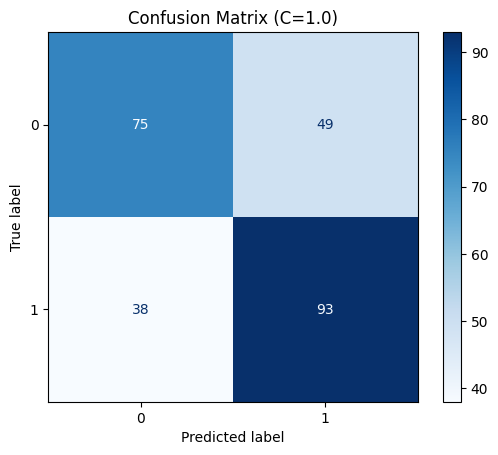

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix (C={model.C})")
plt.show()

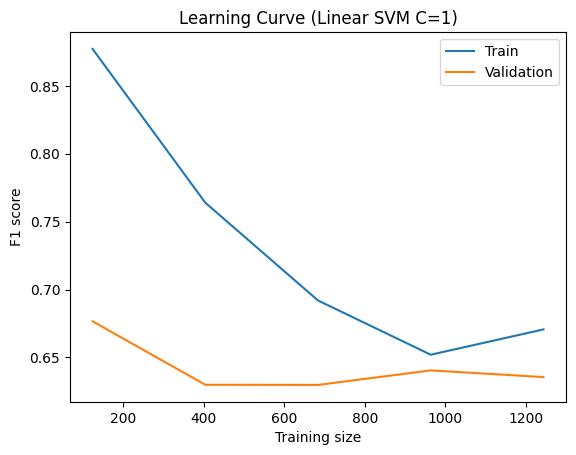

In [59]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',   # importante en tu caso
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Linear SVM C=1)")
plt.legend()
plt.show()

## 7. RBF SVC

In [23]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, recall_score

# -----------------------------
# Define scoring metric
# -----------------------------
# Optimize recall for the positive class (class 1)
recall_pos1 = make_scorer(recall_score, pos_label=1)

# -----------------------------
# Build pipeline
# -----------------------------
# StandardScaler is included inside the pipeline
# so scaling is learned only from the training folds
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# -----------------------------
# Define temporal cross-validation
# -----------------------------
# TimeSeriesSplit preserves temporal order inside training
tscv = TimeSeriesSplit(n_splits=4)

# -----------------------------
# Define hyperparameter grid
# -----------------------------
# Intermediate-sized search for C and gamma
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# -----------------------------
# Grid search
# -----------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=recall_pos1,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# -----------------------------
# Fit grid search on training set only
# -----------------------------
grid.fit(X_train, y_train)

# -----------------------------
# Store best model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Print best results
# -----------------------------
print("Best parameters:")
print(grid.best_params_)

print("\nBest mean CV recall (class 1):")
print(grid.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters:
{'svm__C': 0.1, 'svm__gamma': 1}

Best mean CV recall (class 1):
0.9112156244045797


In [18]:
# Convert CV results into a dataframe
results = pd.DataFrame(grid.cv_results_)

# Keep only useful columns
results = results[[
    "param_svm__C",
    "param_svm__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print(results.head(10))

    param_svm__C param_svm__gamma  mean_test_score  std_test_score  \
4            0.1                1         0.921064        0.040556   
9            1.0                1         0.846191        0.056127   
19         100.0                1         0.835420        0.057382   
14          10.0                1         0.835271        0.060009   
13          10.0              0.1         0.777318        0.075584   
18         100.0              0.1         0.752721        0.090966   
15         100.0            scale         0.751677        0.102188   
3            0.1              0.1         0.740049        0.078730   
17         100.0             0.01         0.735801        0.091018   
10          10.0            scale         0.714408        0.072927   

    rank_test_score  
4                 1  
9                 2  
19                3  
14                4  
13                5  
18                6  
15                7  
3                 8  
17                9  
10       

In [19]:
from sklearn.metrics import recall_score

# Predict on validation set
y_val_pred = best_model.predict(X_val)

# Recall for positive class on validation
val_recall = recall_score(y_val, y_val_pred, pos_label=1)

print("Validation recall (class 1):", val_recall)

Validation recall (class 1): 0.9083969465648855


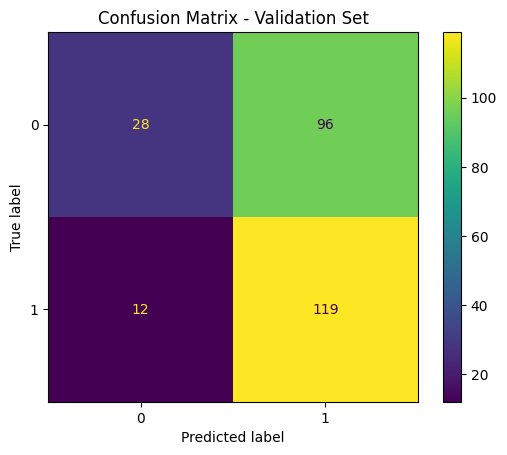

              precision    recall  f1-score     support
0              0.700000  0.225806  0.341463  124.000000
1              0.553488  0.908397  0.687861  131.000000
accuracy       0.576471  0.576471  0.576471    0.576471
macro avg      0.626744  0.567102  0.514662  255.000000
weighted avg   0.624733  0.576471  0.519417  255.000000


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Predict on validation set
y_val_pred = best_model.predict(X_val)

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Classification report as table
# -----------------------------
report_dict = classification_report(y_val, y_val_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print(report_df)

## 7.3 Priortitazing accuracy

In [19]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# -----------------------------
# Build the machine learning pipeline
# -----------------------------
# Step 1: Standardize the features so they have comparable scale
# Step 2: Train an SVM with RBF kernel
# class_weight="balanced" gives more importance to the minority class
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# -----------------------------
# Define temporal cross-validation
# -----------------------------
# TimeSeriesSplit preserves chronological order:
# earlier samples are used for training, later samples for validation
# This is important to avoid temporal leakage
tscv = TimeSeriesSplit(n_splits=4)

# -----------------------------
# Define the hyperparameter search space
# -----------------------------
# C controls how strongly the model penalizes misclassification
# gamma controls how flexible the RBF decision boundary is
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# -----------------------------
# Set up grid search
# -----------------------------
# GridSearchCV will try all combinations of C and gamma
# scoring="accuracy" means models are ranked by mean validation accuracy
# cv=tscv applies temporal cross-validation
# n_jobs=-1 uses all available CPU cores
# refit=True retrains the best model on the full training set at the end
grid_acc = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# -----------------------------
# Fit grid search on the training set only
# -----------------------------
# This tests all parameter combinations using temporal CV
grid_acc.fit(X_train, y_train)

# -----------------------------
# Retrieve the best model
# -----------------------------
# best_estimator_ contains the pipeline with the best hyperparameters found
best_model_acc = grid_acc.best_estimator_

# Print the best hyperparameters
print("Best parameters (accuracy):")
print(grid_acc.best_params_)

# Print the best mean cross-validation accuracy
print("\nBest mean CV accuracy:")
print(grid_acc.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters (accuracy):
{'svm__C': 1, 'svm__gamma': 0.01}

Best mean CV accuracy:
0.6448123539799991


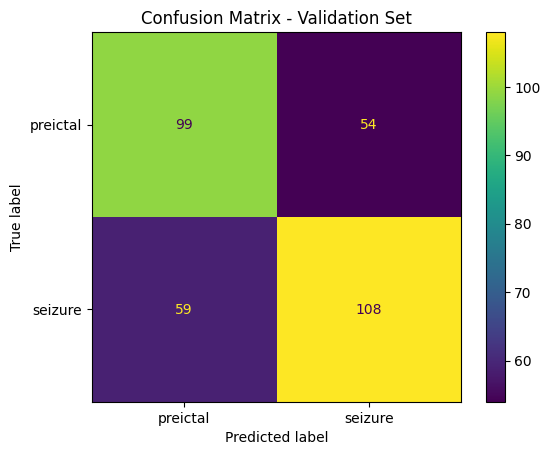

              precision  recall  f1-score  support
preictal          0.627   0.647     0.637  153.000
seizure           0.667   0.647     0.657  167.000
accuracy          0.647   0.647     0.647    0.647
macro avg         0.647   0.647     0.647  320.000
weighted avg      0.648   0.647     0.647  320.000


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Predict on validation set
y_val_pred = best_model_acc.predict(X_val)

# Correct class names
class_names = ["preictal", "seizure"]

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Classification report as table
# -----------------------------
report_dict = classification_report(
    y_val,
    y_val_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose().round(3)
print(report_df)

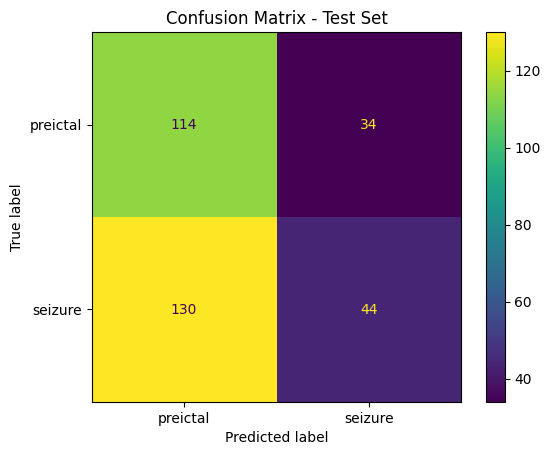

              precision  recall  f1-score  support
preictal          0.467   0.770     0.582  148.000
seizure           0.564   0.253     0.349  174.000
accuracy          0.491   0.491     0.491    0.491
macro avg         0.516   0.512     0.465  322.000
weighted avg      0.520   0.491     0.456  322.000


In [21]:
# Predict on test set
y_test_pred = best_model_acc.predict(X_test)

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification report
report_test = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

report_test_df = pd.DataFrame(report_test).transpose().round(3)
print(report_test_df)

## 8. Removing redundant features and trying again:

In [24]:
import numpy as np
import pandas as pd

# -----------------------------
# Step 1: Remove constant columns
# -----------------------------
# These features have no variation and therefore no predictive value
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

print("Constant columns:")
print(constant_cols)

# Drop constant columns from train/val/test
X_train_red = X_train.drop(columns=constant_cols).copy()
X_val_red = X_val.drop(columns=constant_cols).copy()
X_test_red = X_test.drop(columns=constant_cols).copy()

# -----------------------------
# Step 2: Remove highly correlated columns
# -----------------------------
# Compute absolute correlation matrix only on the training set
corr_matrix = X_train_red.corr().abs()

# Keep only the upper triangle of the correlation matrix
# to avoid checking each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Select columns with correlation above the chosen threshold
# Common thresholds: 0.90, 0.95, 0.98
corr_threshold = 0.95
high_corr_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print("\nHighly correlated columns to remove:")
print(high_corr_cols)

# Drop highly correlated columns from all sets
X_train_red = X_train_red.drop(columns=high_corr_cols).copy()
X_val_red = X_val_red.drop(columns=high_corr_cols).copy()
X_test_red = X_test_red.drop(columns=high_corr_cols).copy()

# -----------------------------
# Step 3: Check final shapes
# -----------------------------
print("\nOriginal X_train shape:", X_train.shape)
print("Reduced X_train shape:", X_train_red.shape)

print("\nFinal features kept:")
print(X_train_red.columns.tolist())

Constant columns:
[]

Highly correlated columns to remove:
['var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C']

Original X_train shape: (1496, 28)
Reduced X_train shape: (1496, 21)

Final features kept:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Build pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# Temporal cross-validation
tscv = TimeSeriesSplit(n_splits=4)

# Hyperparameter grid
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# Grid search using accuracy
grid_acc_red = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Fit on reduced training set
grid_acc_red.fit(X_train_red, y_train)

# Best reduced model
best_model_acc_red = grid_acc_red.best_estimator_

print("Best parameters (reduced features):")
print(grid_acc_red.best_params_)

print("\nBest mean CV accuracy (reduced features):")
print(grid_acc_red.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters (reduced features):
{'svm__C': 1, 'svm__gamma': 0.01}

Best mean CV accuracy (reduced features):
0.6488294314381271


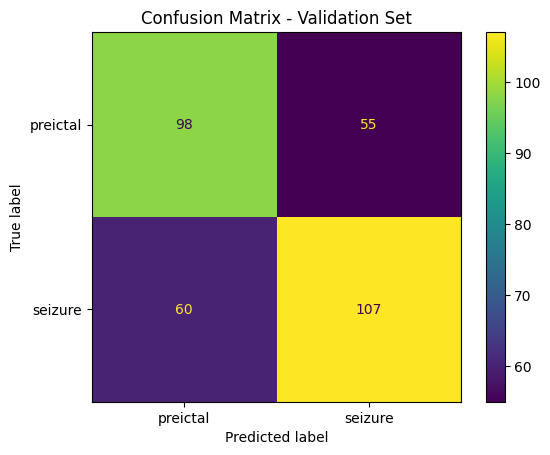

Classification Report - Validation Set
              precision  recall  f1-score  support
preictal          0.620   0.641     0.630  153.000
seizure           0.660   0.641     0.650  167.000
accuracy          0.641   0.641     0.641    0.641
macro avg         0.640   0.641     0.640  320.000
weighted avg      0.641   0.641     0.641  320.000


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Predict on the validation set
# -----------------------------
y_val_pred = best_model_acc_red.predict(X_val_red)

# Define class names according to your mapping
# 0 = preictal
# 1 = seizure
class_names = ["preictal", "seizure"]

# -----------------------------
# Compute and plot confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Generate classification report
# -----------------------------
report_dict = classification_report(
    y_val,
    y_val_pred,
    target_names=class_names,
    output_dict=True
)

# Convert report to a dataframe for cleaner display
report_df = pd.DataFrame(report_dict).transpose().round(3)

print("Classification Report - Validation Set")
print(report_df)

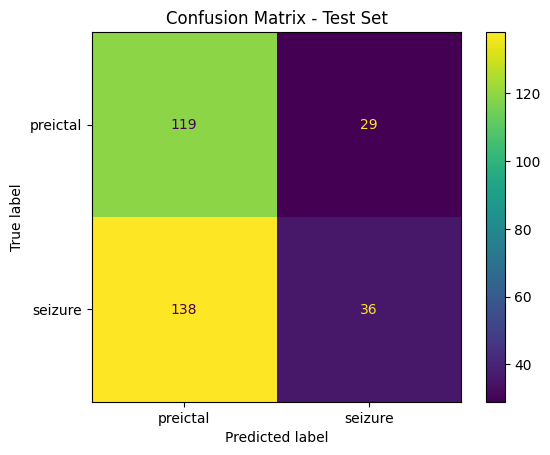

Classification Report - Test Set
              precision  recall  f1-score  support
preictal          0.463   0.804     0.588  148.000
seizure           0.554   0.207     0.301  174.000
accuracy          0.481   0.481     0.481    0.481
macro avg         0.508   0.505     0.444  322.000
weighted avg      0.512   0.481     0.433  322.000


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Predict on the test set
# -----------------------------
y_test_pred = best_model_acc_red.predict(X_test_red)

# Define class names
# 0 = preictal
# 1 = seizure
class_names = ["preictal", "seizure"]

# -----------------------------
# Compute and plot confusion matrix
# -----------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp_test.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# -----------------------------
# Generate classification report
# -----------------------------
report_dict_test = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

# Convert report to dataframe
report_df_test = pd.DataFrame(report_dict_test).transpose().round(3)

print("Classification Report - Test Set")
print(report_df_test)